In [1]:
import polars as pl

# Configure Polars so Jupyter shows ALL columns and a controlled
# number of rows. This prevents truncation and keeps rendering fast.

pl.Config.set_tbl_cols(-1)   # show all columns, no matter how many
pl.Config.set_tbl_rows(150)   # show only 10 rows in the HTML output

# Load the unified tract-quarter feature dataset
df = pl.read_parquet("../../data/processed/feature_engineering/tract_quarter_features.parquet")

df.select([
    "tract_area",
    "tract_perimeter",
    "tract_compactness",
    "elevation_m",
    "centroid_lat",
    "centroid_lon",
]).describe()


statistic,tract_area,tract_perimeter,tract_compactness,elevation_m,centroid_lat,centroid_lon
str,f64,f64,f64,f64,f64,f64
"""count""",10589.0,10589.0,10589.0,10589.0,10589.0,10589.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.01116,0.38647,0.51968,265.002716,43.752892,-89.018974
"""std""",0.02071,0.430195,0.153373,67.435692,0.973915,1.292475
"""min""",0.00002,0.019854,0.120663,176.603333,42.500927,-92.757645
"""25%""",0.000267,0.080795,0.410152,215.14415,43.022629,-89.605179
"""50%""",0.001193,0.178376,0.514083,250.76918,43.313942,-88.475433
"""75%""",0.013165,0.592021,0.640239,293.856018,44.459827,-87.994423
"""max""",0.163613,2.529617,0.826315,556.044373,46.926899,-86.98954


In [2]:
df.select([
    pl.corr("reliability_index", col).alias(col)
    for col in [
        "tract_area",
        "tract_perimeter",
        "tract_compactness",
        "elevation_m",
        "centroid_lat",
        "centroid_lon",
    ]
])


tract_area,tract_perimeter,tract_compactness,elevation_m,centroid_lat,centroid_lon
f64,f64,f64,f64,f64,f64
-0.439084,-0.521061,0.21304,-0.321336,-0.323557,0.24741


In [3]:
density_cols = [
    "population_total",
    "housing_units",
    "tests_total",
    "devices_total",
]

for geom in ["tract_area", "tract_perimeter", "tract_compactness"]:
    print(f"\n=== {geom} correlations ===")
    print(df.select([
        pl.corr(geom, d).alias(d)
        for d in density_cols
    ]))



=== tract_area correlations ===
shape: (1, 4)
┌──────────────────┬───────────────┬─────────────┬───────────────┐
│ population_total ┆ housing_units ┆ tests_total ┆ devices_total │
│ ---              ┆ ---           ┆ ---         ┆ ---           │
│ f64              ┆ f64           ┆ f64         ┆ f64           │
╞══════════════════╪═══════════════╪═════════════╪═══════════════╡
│ -0.081709        ┆ 0.180055      ┆ 0.100231    ┆ 0.145995      │
└──────────────────┴───────────────┴─────────────┴───────────────┘

=== tract_perimeter correlations ===
shape: (1, 4)
┌──────────────────┬───────────────┬─────────────┬───────────────┐
│ population_total ┆ housing_units ┆ tests_total ┆ devices_total │
│ ---              ┆ ---           ┆ ---         ┆ ---           │
│ f64              ┆ f64           ┆ f64         ┆ f64           │
╞══════════════════╪═══════════════╪═════════════╪═══════════════╡
│ -0.014384        ┆ 0.227133      ┆ 0.165589    ┆ 0.218933      │
└──────────────────┴──────────

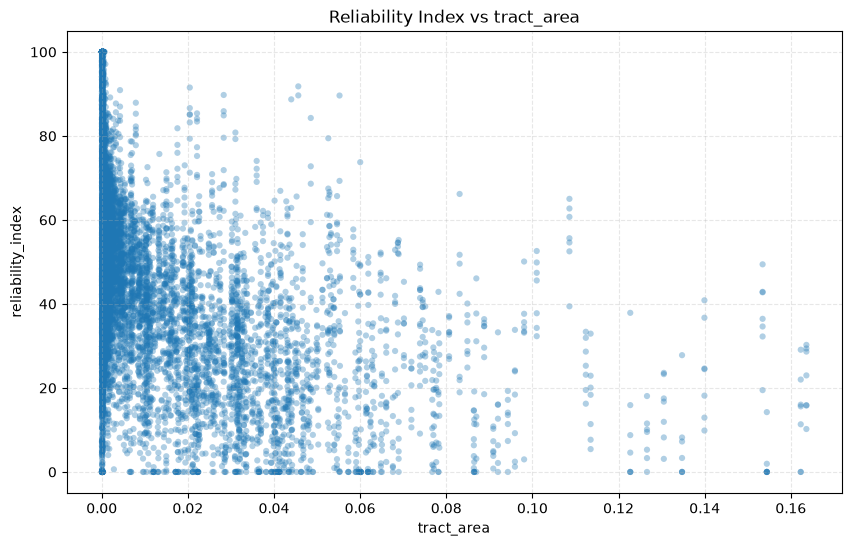

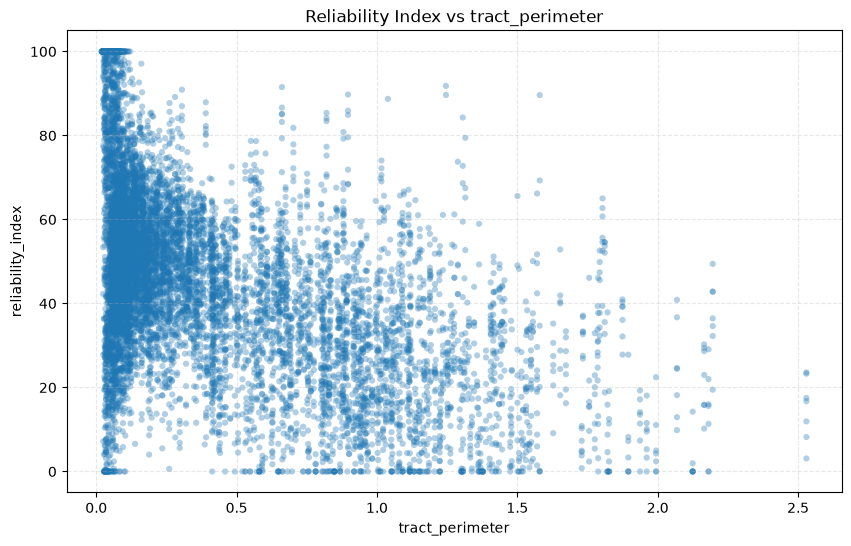

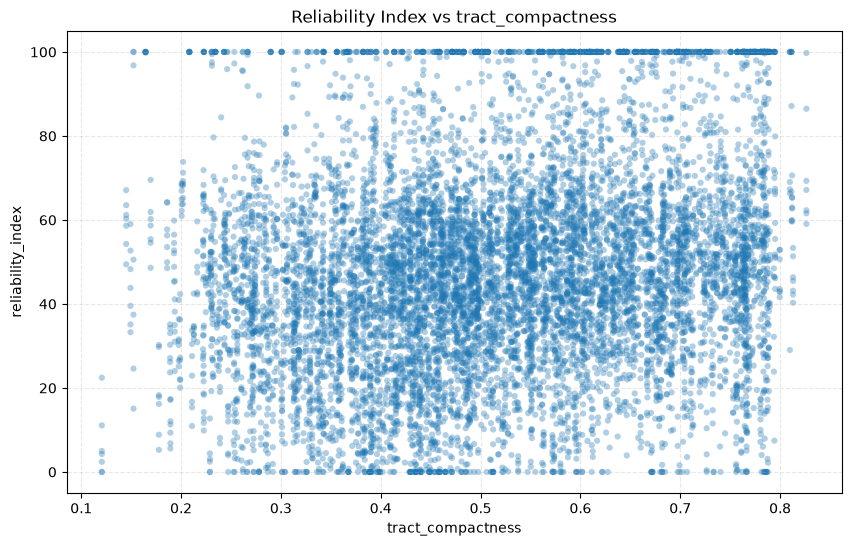

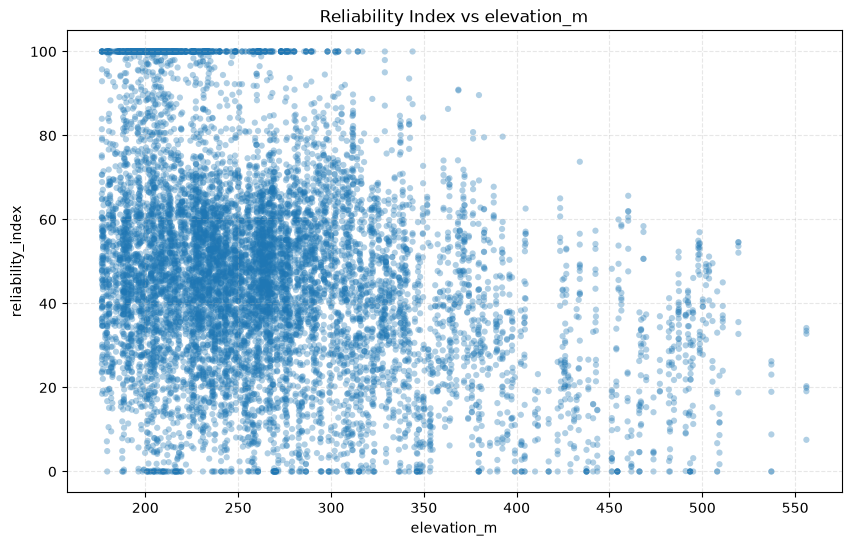

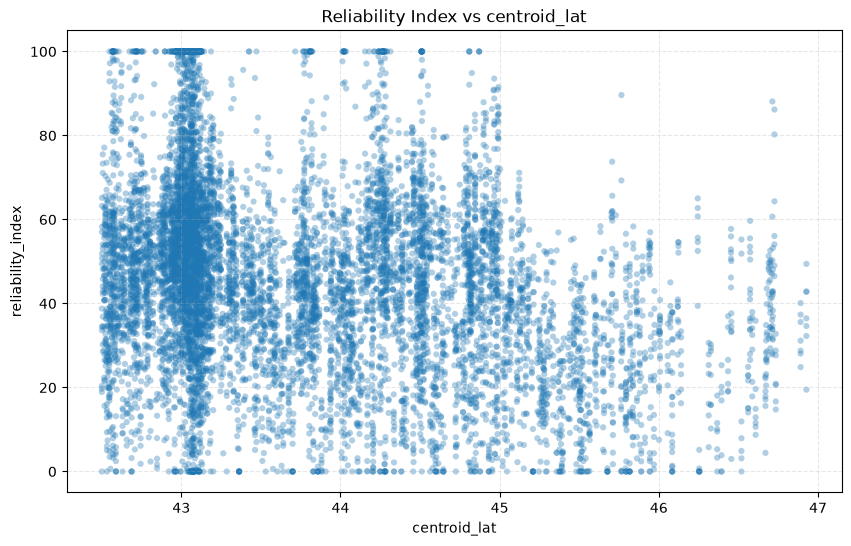

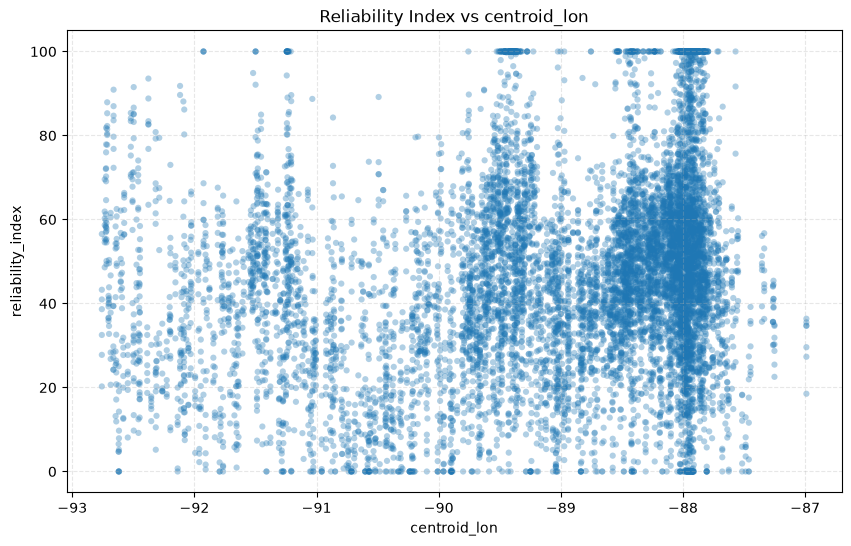

In [5]:
import matplotlib.pyplot as plt

geom_cols = [
    "tract_area",
    "tract_perimeter",
    "tract_compactness",
    "elevation_m",
    "centroid_lat",
    "centroid_lon",
]

for col in geom_cols:
    plt.figure(figsize=(10, 6))
    plt.scatter(
        df[col],
        df["reliability_index"],
        alpha=0.35,
        s=20,
        edgecolor="none"
    )
    plt.title(f"Reliability Index vs {col}")
    plt.xlabel(col)
    plt.ylabel("reliability_index")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

